# 01. Análisis Exploratorio de Datos (EDA) y Limpieza
Este notebook contiene el primer paso del proyecto de regresión, realizaremos un estudio detallado de la calidad de los datos antes de proceder a su limpieza y transformación.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
df = pd.read_csv('../data/raw/data.csv', encoding='ISO-8859-1')

# Configuración visual
%matplotlib inline
print(f"[INFO] Dimensiones iniciales: {df.shape}")
df.head()

[INFO] Dimensiones iniciales: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Análisis Exploratorio y Calidad de Datos
En esta fase estudiaremos las columnas para entender su significado y detectar anomalías

In [11]:
# Ver tipos de datos y nulos totales
print("[INFO] Información General: ")
display(df.info())

print("\n[INFO] Valores Faltantes por columna: ")
# Observamos los valores nullos que son críticos
print(df.isnull().sum())

[INFO] Información General: 
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


None


[INFO] Valores Faltantes por columna: 
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [12]:
# Observamos la estadísticas descriptivas para detectar valores incoherentes
# Buscamos cantidades negativas (devoluciones) o precios de 0
display(df.describe())

# Ver distribución de países
print("\n[INFO] Distribución por País (Top 10): ")
print(df['Country'].value_counts().head(10))

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000



[INFO] Distribución por País (Top 10): 
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


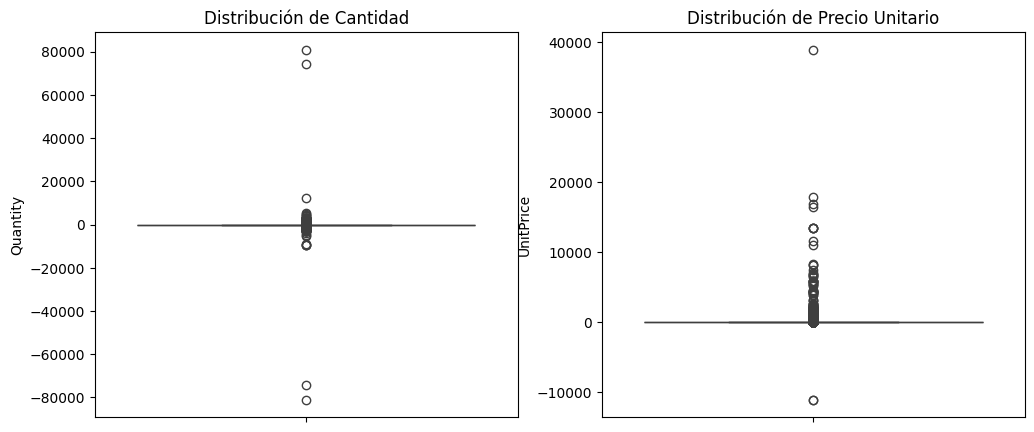

In [13]:
# Gráficos para identificar visualmente valores extremos que distorsionen el modelo
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Distribución de Cantidad')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['UnitPrice'])
plt.title('Distribución de Precio Unitario')

plt.show()

## Limpieza de Datos
Tras el análisis, procederemos a limpiar los valores incorrectos de manera subjetiva para mejorar la precisión del modelo.

In [14]:
# Eliminamos filas sin CustomerID ya que es crítico para el análisis
df_clean = df.dropna(subset=['CustomerID'])

# Filtramos solo transacciones de venta (Quantity > 0)
df_clean = df_clean[df_clean['Quantity'] > 0]

# Eliminamos registros con UnitPrice <= 0
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Debemos mantener el 95% de los datos, para ello filtramos valores extremos por encima del percentil 95 o 99
q_limit = df_clean['Quantity'].quantile(0.99)
df_clean = df_clean[df_clean['Quantity'] <= q_limit]

print(f"[INFO] Dimensiones tras la limpieza: {df_clean.shape}")

[INFO] Dimensiones tras la limpieza: (393994, 8)


In [ ]:
# Creamos la variable "Sales" (Ventas) necesaria para la regresión 
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Convertimos el campo InvoiceDate a tipo datetime para análisis temporal
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Guardar el dataset procesado para el siguiente archivo notebook
df_clean.to_csv('../data/processed/data_cleaned.csv', index=False)
print("[SUCCESS] Dataset limpio y guardado en data/processed/")

Dataset limpio y guardado en data/processed/


## Conclusiones
En la fase exploratoria identificamos varias fuentes de distorsión: transacciones incompletas, outliers de precio, devoluciones y 135.080 nulos en la columna de identificación de clientes. Con eso sobre la mesa, agregamos los datos en una serie temporal diaria que muestra una tendencia al alza hacia el cierre de 2011. Para el modelo de regresión descartaremos las cantidades negativas y recortaremos los extremos en el percentil 95 — dos decisiones pensadas para que el entrenamiento sea lo más estable posible. El dataset limpio está en data/processed/data_cleaned.csv.